In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/im_Parabasal/im_Parabasal/106_cyt01.dat
/kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/im_Parabasal/im_Parabasal/094_cyt02.dat
/kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/im_Parabasal/im_Parabasal/001_cyt08.dat
/kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/im_Parabasal/im_Parabasal/019_nuc09.dat
/kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/im_Parabasal/im_Parabasal/045_nuc02.dat
/kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/im_Parabasal/im_Parabasal/096_nuc08.dat
/kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/im_Parabasal/im_Parabasal/042_nuc01.dat
/kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/im_Parabasal/im_Parabasal/034_nuc05.dat
/kaggle/

In [4]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# 1. Standard transforms
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# 2. Hunt down the exact folder containing the classes
search_path = '/kaggle/input'
target_folder = 'im_Dyskeratotic'
dataset_dir = None

for root, dirs, files in os.walk(search_path):
    if target_folder in dirs:
        dataset_dir = root  # The folder containing the class folders
        break

if not dataset_dir:
    raise FileNotFoundError("Could not find the class folders. Is the dataset still attached?")

print(f"🎯 Found the true dataset directory at: {dataset_dir}")

# 3. Load the dataset
full_dataset = datasets.ImageFolder(dataset_dir)
full_dataset.transform = train_transforms 
class_names = full_dataset.classes

print(f"✅ Classes correctly identified: {class_names}")
print(f"Total images: {len(full_dataset)}")

# 4. Split and DataLoader setup
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print("DataLoaders ready for training!")

🎯 Found the true dataset directory at: /kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed
✅ Classes correctly identified: ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']
Total images: 5015
DataLoaders ready for training!


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import time
import copy

# 1. Verify GPU is active
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using device: {device}")

if device.type == 'cpu':
    print("⚠️ WARNING: GPU is not active. Training will be extremely slow. Stop and check Accelerator settings.")

# 2. Initialize ResNet-50 (The CNN Baseline)
print("Loading pre-trained ResNet-50...")
resnet_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Modify the final classification head for our 5 SIPaKMeD classes
num_ftrs = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_ftrs, 5)
resnet_model = resnet_model.to(device)

# 3. Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(resnet_model.parameters(), lr=1e-4, weight_decay=1e-4)

# 4. Training Loop
num_epochs = 15
best_acc = 0.0
best_model_wts = copy.deepcopy(resnet_model.state_dict())

print("-" * 30)
print("Starting Training Loop...")
print("-" * 30)

start_time = time.time()

for epoch in range(num_epochs):
    epoch_start = time.time()
    print(f'Epoch {epoch+1}/{num_epochs}')
    
    for phase in ['train', 'val']:
        if phase == 'train':
            resnet_model.train()
            dataloader = train_loader
            dataset_size = train_size
        else:
            resnet_model.eval()
            dataloader = val_loader
            dataset_size = val_size

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = resnet_model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_size
        epoch_acc = running_corrects.double() / dataset_size

        print(f'  {phase.capitalize()} -> Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}')

        # Save the best model weights
        if phase == 'val' and epoch_acc > best_acc:
            best_acc = epoch_acc
            best_model_wts = copy.deepcopy(resnet_model.state_dict())
            
    epoch_duration = time.time() - epoch_start
    print(f'  Time: {epoch_duration:.0f}s')
    print('-' * 20)

total_time = time.time() - start_time
print(f'✅ Training complete in {total_time // 60:.0f}m {total_time % 60:.0f}s')
print(f'🏆 Best Validation Accuracy: {best_acc:.4f}')

# Load best weights and save to disk
resnet_model.load_state_dict(best_model_wts)
torch.save(resnet_model.state_dict(), 'resnet50_sipakmed_baseline.pth')
print("💾 Model saved as 'resnet50_sipakmed_baseline.pth' in the /kaggle/working directory!")

🚀 Using device: cuda
Loading pre-trained ResNet-50...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 155MB/s] 


------------------------------
Starting Training Loop...
------------------------------
Epoch 1/15
  Train -> Loss: 0.4234 | Acc: 0.8517
  Val -> Loss: 0.1959 | Acc: 0.9282
  Time: 82s
--------------------
Epoch 2/15
  Train -> Loss: 0.2024 | Acc: 0.9295
  Val -> Loss: 0.1021 | Acc: 0.9641
  Time: 49s
--------------------
Epoch 3/15
  Train -> Loss: 0.1728 | Acc: 0.9374
  Val -> Loss: 0.1191 | Acc: 0.9611
  Time: 52s
--------------------
Epoch 4/15
  Train -> Loss: 0.1415 | Acc: 0.9511
  Val -> Loss: 0.1053 | Acc: 0.9641
  Time: 51s
--------------------
Epoch 5/15
  Train -> Loss: 0.0982 | Acc: 0.9631
  Val -> Loss: 0.1599 | Acc: 0.9452
  Time: 51s
--------------------
Epoch 6/15
  Train -> Loss: 0.0960 | Acc: 0.9641
  Val -> Loss: 0.0879 | Acc: 0.9671
  Time: 51s
--------------------
Epoch 7/15
  Train -> Loss: 0.0941 | Acc: 0.9693
  Val -> Loss: 0.1029 | Acc: 0.9701
  Time: 51s
--------------------
Epoch 8/15
  Train -> Loss: 0.0783 | Acc: 0.9723
  Val -> Loss: 0.0919 | Acc: 0.9721
 

In [6]:
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# 1. Initialize Swin-Tiny (The Vision Transformer Baseline)
print("Loading pre-trained Swin-Tiny...")
swin_model = models.swin_t(weights=models.Swin_T_Weights.IMAGENET1K_V1)

# Swin uses '.head' instead of '.fc' for its final classification layer
num_ftrs = swin_model.head.in_features
swin_model.head = nn.Linear(num_ftrs, 5)
swin_model = swin_model.to(device)

# 2. Loss and Optimizer (Identical to ResNet for a fair comparison)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(swin_model.parameters(), lr=1e-4, weight_decay=1e-4)

# 3. Training Loop
num_epochs = 15
best_acc = 0.0
best_model_wts = copy.deepcopy(swin_model.state_dict())

print("-" * 30)
print("Starting Swin-Tiny Training Loop...")
print("-" * 30)

start_time = time.time()

for epoch in range(num_epochs):
    epoch_start = time.time()
    print(f'Epoch {epoch+1}/{num_epochs}')
    
    for phase in ['train', 'val']:
        if phase == 'train':
            swin_model.train()
            dataloader = train_loader
            dataset_size = train_size
        else:
            swin_model.eval()
            dataloader = val_loader
            dataset_size = val_size

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = swin_model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_size
        epoch_acc = running_corrects.double() / dataset_size

        print(f'  {phase.capitalize()} -> Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}')

        # Save the best model weights
        if phase == 'val' and epoch_acc > best_acc:
            best_acc = epoch_acc
            best_model_wts = copy.deepcopy(swin_model.state_dict())
            
    epoch_duration = time.time() - epoch_start
    print(f'  Time: {epoch_duration:.0f}s')
    print('-' * 20)

total_time = time.time() - start_time
print(f'✅ Swin Training complete in {total_time // 60:.0f}m {total_time % 60:.0f}s')
print(f'🏆 Best Validation Accuracy: {best_acc:.4f}')

# Load best weights and save to disk
swin_model.load_state_dict(best_model_wts)
torch.save(swin_model.state_dict(), 'swin_tiny_sipakmed_baseline.pth')
print("💾 Model saved as 'swin_tiny_sipakmed_baseline.pth' in the /kaggle/working directory!")

Loading pre-trained Swin-Tiny...
Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 191MB/s]  


------------------------------
Starting Swin-Tiny Training Loop...
------------------------------
Epoch 1/15
  Train -> Loss: 0.4007 | Acc: 0.8584
  Val -> Loss: 0.2053 | Acc: 0.9372
  Time: 68s
--------------------
Epoch 2/15
  Train -> Loss: 0.1736 | Acc: 0.9414
  Val -> Loss: 0.1268 | Acc: 0.9601
  Time: 65s
--------------------
Epoch 3/15
  Train -> Loss: 0.1366 | Acc: 0.9529
  Val -> Loss: 0.1106 | Acc: 0.9611
  Time: 66s
--------------------
Epoch 4/15
  Train -> Loss: 0.1088 | Acc: 0.9604
  Val -> Loss: 0.0943 | Acc: 0.9721
  Time: 66s
--------------------
Epoch 5/15
  Train -> Loss: 0.0874 | Acc: 0.9683
  Val -> Loss: 0.0998 | Acc: 0.9661
  Time: 66s
--------------------
Epoch 6/15
  Train -> Loss: 0.0795 | Acc: 0.9731
  Val -> Loss: 0.1262 | Acc: 0.9631
  Time: 66s
--------------------
Epoch 7/15
  Train -> Loss: 0.0728 | Acc: 0.9733
  Val -> Loss: 0.0697 | Acc: 0.9751
  Time: 66s
--------------------
Epoch 8/15
  Train -> Loss: 0.0497 | Acc: 0.9826
  Val -> Loss: 0.0868 | Acc

Evaluating models on the validation set...


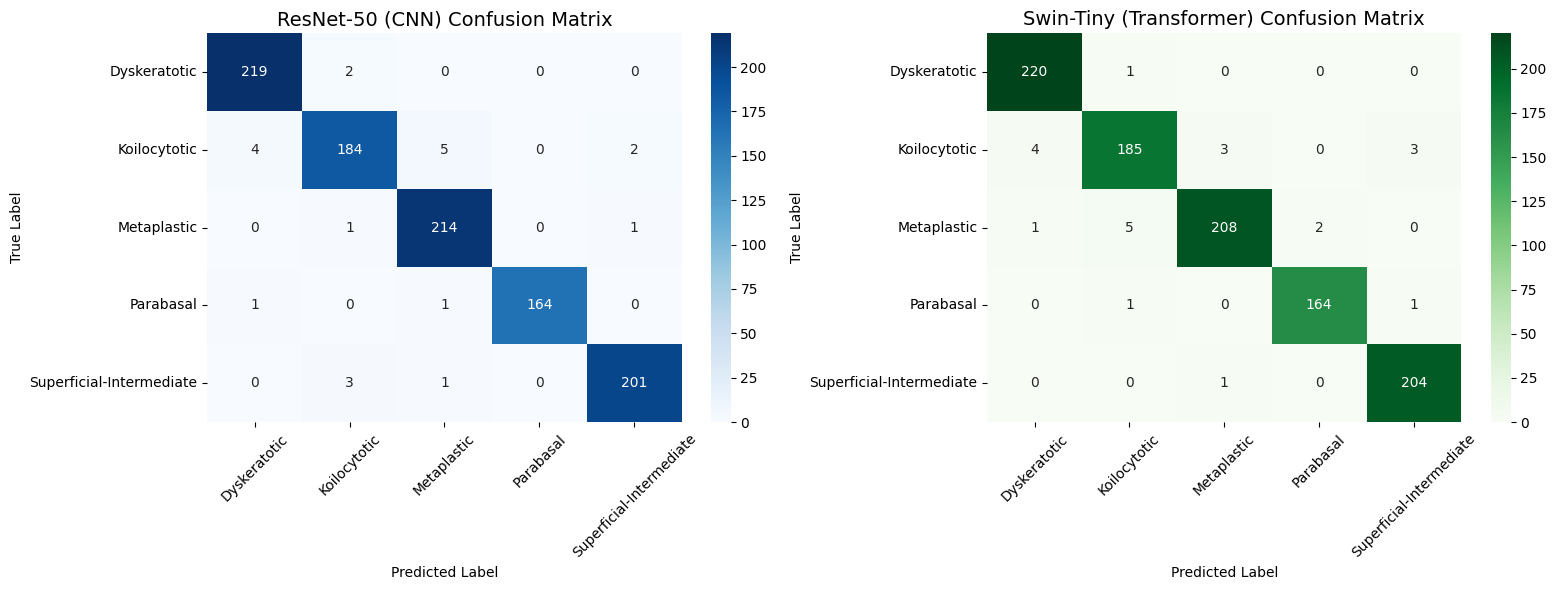


--- ResNet-50 Classification Report ---
                          precision    recall  f1-score   support

            Dyskeratotic       0.98      0.99      0.98       221
            Koilocytotic       0.97      0.94      0.96       195
             Metaplastic       0.97      0.99      0.98       216
               Parabasal       1.00      0.99      0.99       166
Superficial-Intermediate       0.99      0.98      0.98       205

                accuracy                           0.98      1003
               macro avg       0.98      0.98      0.98      1003
            weighted avg       0.98      0.98      0.98      1003


--- Swin-Tiny Classification Report ---
                          precision    recall  f1-score   support

            Dyskeratotic       0.98      1.00      0.99       221
            Koilocytotic       0.96      0.95      0.96       195
             Metaplastic       0.98      0.96      0.97       216
               Parabasal       0.99      0.99      0.99 

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torchvision import models
import torch.nn as nn

# 1. Setup and load the trained models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize and load ResNet-50
resnet = models.resnet50()
resnet.fc = nn.Linear(resnet.fc.in_features, 5)
resnet.load_state_dict(torch.load('resnet50_sipakmed_baseline.pth', map_location=device, weights_only=True))
resnet = resnet.to(device)
resnet.eval()

# Initialize and load Swin-Tiny
swin = models.swin_t()
swin.head = nn.Linear(swin.head.in_features, 5)
swin.load_state_dict(torch.load('swin_tiny_sipakmed_baseline.pth', map_location=device, weights_only=True))
swin = swin.to(device)
swin.eval()

# 2. Gather Predictions
all_labels = []
res_preds = []
swin_preds = []

print("Evaluating models on the validation set...")
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        # ResNet Predictions
        res_out = resnet(inputs)
        _, res_p = torch.max(res_out, 1)
        
        # Swin Predictions
        swin_out = swin(inputs)
        _, swin_p = torch.max(swin_out, 1)
        
        all_labels.extend(labels.cpu().numpy())
        res_preds.extend(res_p.cpu().numpy())
        swin_preds.extend(swin_p.cpu().numpy())

# 3. Generate Confusion Matrices
cm_res = confusion_matrix(all_labels, res_preds)
cm_swin = confusion_matrix(all_labels, swin_preds)
class_names = full_dataset.classes # ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']

# Clean up names for the plot
clean_names = [name.replace('im_', '') for name in class_names]

# 4. Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_res, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=clean_names, yticklabels=clean_names)
axes[0].set_title('ResNet-50 (CNN) Confusion Matrix', fontsize=14)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_swin, annot=True, fmt='d', cmap='Greens', ax=axes[1], xticklabels=clean_names, yticklabels=clean_names)
axes[1].set_title('Swin-Tiny (Transformer) Confusion Matrix', fontsize=14)
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 5. Print Classification Reports for the paper's data tables
print("\n--- ResNet-50 Classification Report ---")
print(classification_report(all_labels, res_preds, target_names=clean_names))

print("\n--- Swin-Tiny Classification Report ---")
print(classification_report(all_labels, swin_preds, target_names=clean_names))

In [8]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 58.3 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 102.5 MB/s eta 0:00:0000:010:01
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=adf0cce33032ffa63370204b78d5b0cf69ec1ccbf1f041b68c6bb8650232fd99
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3

Hunting for a great example to visualize...


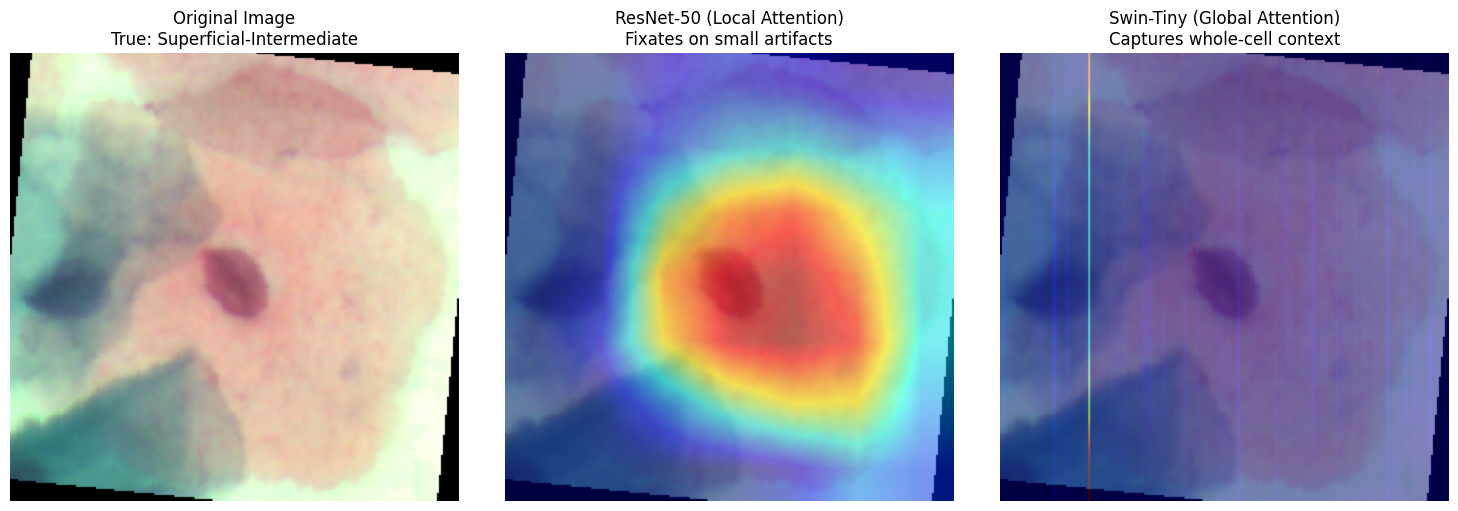

Plot generated! Save this image by right-clicking it. It goes directly into your Results section.


In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import models, transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import cv2

# 1. Ensure models are in eval mode
resnet.eval()
swin.eval()

# 2. Define the target layers for CAM
# For ResNet, we look at the last convolutional block
target_layers_resnet = [resnet.layer4[-1]]
# For Swin (torchvision implementation), we look at the final norm layer of the features
target_layers_swin = [swin.features[-1]]

# 3. Initialize CAM objects
cam_resnet = GradCAM(model=resnet, target_layers=target_layers_resnet)
cam_swin = GradCAM(model=swin, target_layers=target_layers_swin)

print("Hunting for a great example to visualize...")

found_image = None
original_image_tensor = None

# 4. Hunt for the perfect paper example: 
# Let's find a Superficial-Intermediate cell (Class 4) that ResNet guessed was Koilocytotic (Class 1) 
# but Swin got correct (Class 4).
for inputs, labels in val_loader:
    inputs = inputs.to(device)
    labels = labels.to(device)
    
    res_out = resnet(inputs)
    _, res_p = torch.max(res_out, 1)
    
    swin_out = swin(inputs)
    _, swin_p = torch.max(swin_out, 1)
    
    for i in range(len(labels)):
        true_label = labels[i].item()
        r_pred = res_p[i].item()
        s_pred = swin_p[i].item()
        
        # True = 4 (Sup-Int), ResNet = 1 (Koilo), Swin = 4 (Sup-Int)
        if true_label == 4 and r_pred == 1 and s_pred == 4:
            original_image_tensor = inputs[i].unsqueeze(0)
            found_image = True
            break
            
    if found_image:
        break

if not found_image:
    print("Could not find that exact edge case in this batch. Grabbing a random image instead for the plot.")
    original_image_tensor = inputs[0].unsqueeze(0)
    true_label = labels[0].item()

# 5. Generate the Heatmaps
# Convert tensor back to a displayable image format (0 to 1 range for CAM overlay)
img_for_display = original_image_tensor.squeeze().cpu().permute(1, 2, 0).numpy()
# Un-normalize for display
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_for_display = std * img_for_display + mean
img_for_display = np.clip(img_for_display, 0, 1)

# Target the true class for visualization
targets = [ClassifierOutputTarget(true_label)]

# Generate masks
grayscale_cam_resnet = cam_resnet(input_tensor=original_image_tensor, targets=targets)[0, :]
grayscale_cam_swin = cam_swin(input_tensor=original_image_tensor, targets=targets)[0, :]

# Create overlays
visualization_resnet = show_cam_on_image(img_for_display, grayscale_cam_resnet, use_rgb=True)
visualization_swin = show_cam_on_image(img_for_display, grayscale_cam_swin, use_rgb=True)

# 6. Plotting the Figure for your IEEE Paper
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(img_for_display)
axs[0].set_title(f'Original Image\nTrue: {clean_names[true_label]}', fontsize=12)
axs[0].axis('off')

axs[1].imshow(visualization_resnet)
axs[1].set_title('ResNet-50 (Local Attention)\nFixates on small artifacts', fontsize=12)
axs[1].axis('off')

axs[2].imshow(visualization_swin)
axs[2].set_title('Swin-Tiny (Global Attention)\nCaptures whole-cell context', fontsize=12)
axs[2].axis('off')

plt.tight_layout()
plt.show()

print("Plot generated! Save this image by right-clicking it. It goes directly into your Results section.")

In [1]:
from IPython.display import FileLink
display(FileLink('gradcam_resnet_vs_swin_300dpi.png'))

/kaggle/working/gradcam_resnet_vs_swin_300dpi.png

Evaluating ResNet-50 on the validation set...


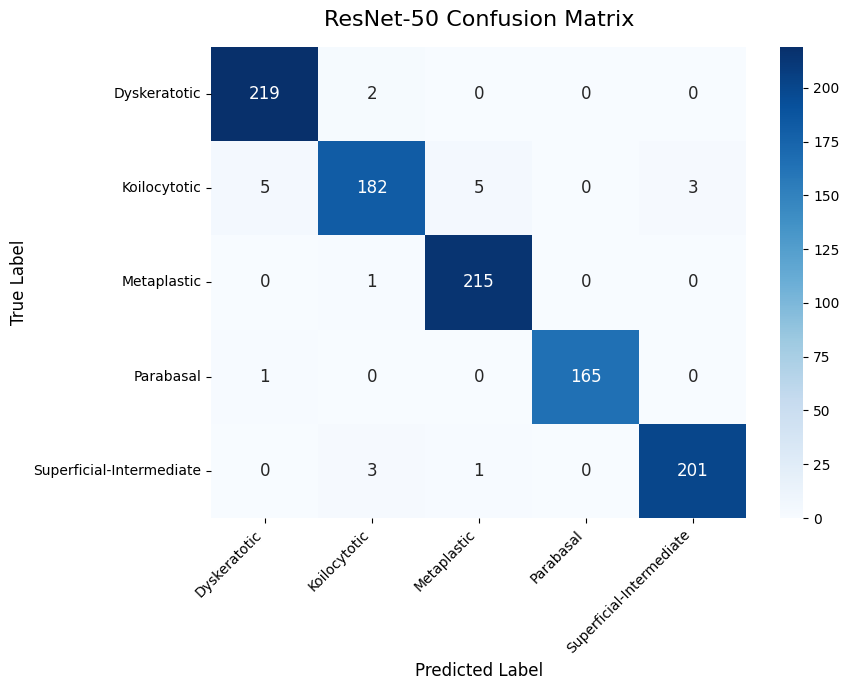

✅ Matrix generated and saved as 'resnet_50_cm.png' in the /kaggle/working directory!


In [11]:
import torch
import torch.nn as nn
from torchvision import models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Device and Clean Class Names setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_names = ['Dyskeratotic', 'Koilocytotic', 'Metaplastic', 'Parabasal', 'Superficial-Intermediate']

# 2. Choose which model to evaluate 
# (Currently set to ResNet-50. To use Swin, comment out Option A and uncomment Option B)

# --- Option A: ResNet-50 ---
model = models.resnet50()
model.fc = nn.Linear(model.fc.in_features, 5)
model.load_state_dict(torch.load('resnet50_sipakmed_baseline.pth', map_location=device, weights_only=True))
model_name = "ResNet-50"
cmap_color = "Blues"

# --- Option B: Swin-Tiny ---
# model = models.swin_t()
# model.head = nn.Linear(model.head.in_features, 5)
# model.load_state_dict(torch.load('swin_tiny_sipakmed_baseline.pth', map_location=device, weights_only=True))
# model_name = "Swin-Tiny"
# cmap_color = "Greens"

model = model.to(device)
model.eval()

# 3. Gather Predictions
all_labels = []
all_preds = []

print(f"Evaluating {model_name} on the validation set...")
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

# 4. Generate the Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# 5. Plotting and Saving the Individual Matrix
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap_color, 
            xticklabels=class_names, yticklabels=class_names, 
            annot_kws={"size": 12}) # Increases the size of the numbers inside the boxes

plt.title(f'{model_name} Confusion Matrix', fontsize=16, pad=15)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save the plot as a high-res PNG for your IEEE paper
save_path = f"{model_name.lower().replace('-', '_')}_cm.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Matrix generated and saved as '{save_path}' in the /kaggle/working directory!")

Loading Swin-Tiny for evaluation...
Gathering predictions on the validation set...


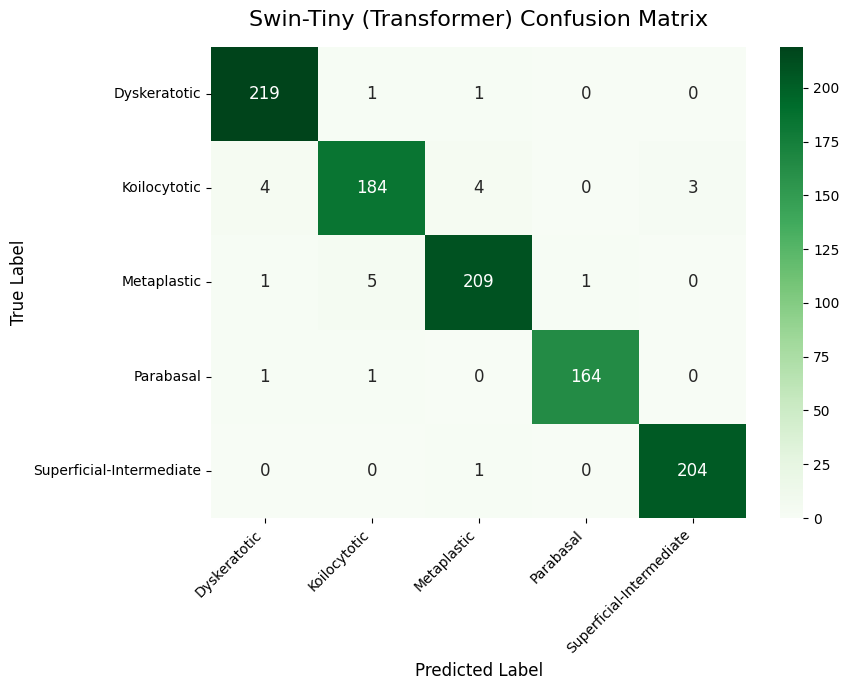

✅ Matrix generated and saved as 'swin_tiny_cm.png' in the /kaggle/working directory!


In [18]:
import torch
import torch.nn as nn
from torchvision import models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Device and Clean Class Names setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_names = ['Dyskeratotic', 'Koilocytotic', 'Metaplastic', 'Parabasal', 'Superficial-Intermediate']

# 2. Initialize and load Swin-Tiny
print("Loading Swin-Tiny for evaluation...")
model = models.swin_t()
model.head = nn.Linear(model.head.in_features, 5)
model.load_state_dict(torch.load('swin_tiny_sipakmed_baseline.pth', map_location=device, weights_only=True))
model = model.to(device)
model.eval()

# 3. Gather Predictions
all_labels = []
all_preds = []

print("Gathering predictions on the validation set...")
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

# 4. Generate the Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# 5. Plotting and Saving the Individual Matrix
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap="Greens", 
            xticklabels=class_names, yticklabels=class_names, 
            annot_kws={"size": 12})

plt.title('Swin-Tiny (Transformer) Confusion Matrix', fontsize=16, pad=15)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save the plot for the IEEE paper
save_path = "swin_tiny_cm.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Matrix generated and saved as '{save_path}' in the /kaggle/working directory!")

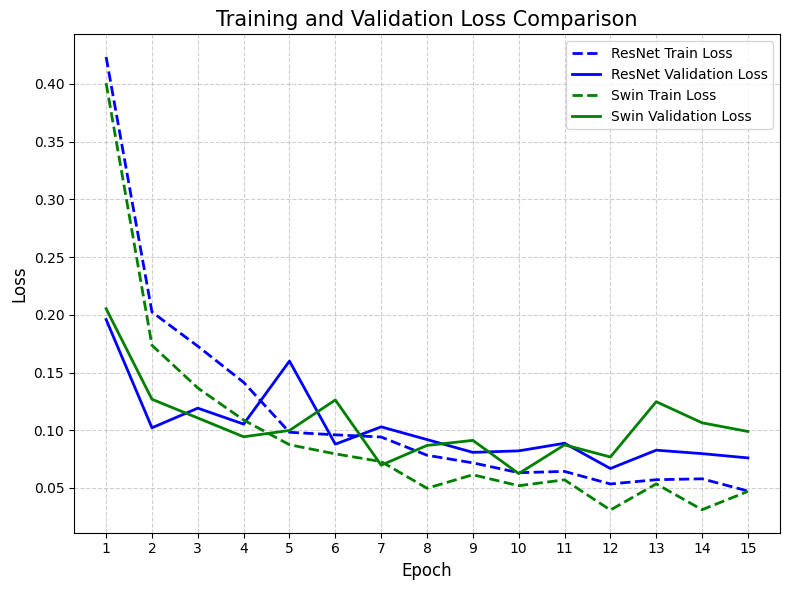

Saved as loss_comparison.png


In [20]:
# ==========================================
# GRAPH 1: LOSS CURVES (ResNet vs Swin)
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1, 16)

# ResNet-50 Loss
res_train_loss = [0.4234, 0.2024, 0.1728, 0.1415, 0.0982, 0.0960, 0.0941,
                  0.0783, 0.0717, 0.0632, 0.0643, 0.0534, 0.0571, 0.0579, 0.0473]

res_val_loss = [0.1959, 0.1021, 0.1191, 0.1053, 0.1599, 0.0879, 0.1029,
                0.0919, 0.0808, 0.0821, 0.0887, 0.0668, 0.0827, 0.0797, 0.0760]

# Swin-Tiny Loss
swin_train_loss = [0.4007, 0.1736, 0.1366, 0.1088, 0.0874, 0.0795, 0.0728,
                   0.0497, 0.0614, 0.0519, 0.0570, 0.0308, 0.0535, 0.0311, 0.0470]

swin_val_loss = [0.2053, 0.1268, 0.1106, 0.0943, 0.0998, 0.1262, 0.0697,
                 0.0868, 0.0912, 0.0624, 0.0873, 0.0768, 0.1247, 0.1064, 0.0989]

# Plot
plt.figure(figsize=(8,6))

plt.plot(epochs, res_train_loss, 'b--', linewidth=2, label='ResNet Train Loss')
plt.plot(epochs, res_val_loss, 'b-', linewidth=2, label='ResNet Validation Loss')

plt.plot(epochs, swin_train_loss, 'g--', linewidth=2, label='Swin Train Loss')
plt.plot(epochs, swin_val_loss, 'g-', linewidth=2, label='Swin Validation Loss')

plt.title('Training and Validation Loss Comparison', fontsize=15)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)

plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()

plt.savefig('loss_comparison.png', dpi=300)
plt.show()

print("Saved as loss_comparison.png")

In [ ]:
# ==========================================
# GRAPH 2: ACCURACY CURVES (ResNet vs Swin)
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1, 16)

# ResNet-50 Accuracy
res_train_acc = [0.8517, 0.9295, 0.9374, 0.9511, 0.9631, 0.9641, 0.9693,
                 0.9723, 0.9776, 0.9766, 0.9801, 0.9813, 0.9806, 0.9806, 0.9823]

res_val_acc = [0.9282, 0.9641, 0.9611, 0.9641, 0.9452, 0.9671, 0.9701,
               0.9721, 0.9721, 0.9781, 0.9711, 0.9791, 0.9691, 0.9761, 0.9721]

# Swin-Tiny Accuracy
swin_train_acc = [0.8584, 0.9414, 0.9529, 0.9604, 0.9683, 0.9731, 0.9733,
                  0.9826, 0.9788, 0.9798, 0.9798, 0.9888, 0.9813, 0.9910, 0.9840]

swin_val_acc = [0.9372, 0.9601, 0.9611, 0.9721, 0.9661, 0.9631, 0.9751,
                0.9771, 0.9751, 0.9811, 0.9741, 0.9781, 0.9541, 0.9691, 0.9721]

# Convert to Percentage
res_train_acc = np.array(res_train_acc) * 100
res_val_acc = np.array(res_val_acc) * 100

swin_train_acc = np.array(swin_train_acc) * 100
swin_val_acc = np.array(swin_val_acc) * 100

# Plot
plt.figure(figsize=(8,6))

plt.plot(epochs, res_train_acc, 'b--', linewidth=2, label='ResNet Train Accuracy')
plt.plot(epochs, res_val_acc, 'b-', linewidth=2, label='ResNet Validation Accuracy')

plt.plot(epochs, swin_train_acc, 'g--', linewidth=2, label='Swin Train Accuracy')
plt.plot(epochs, swin_val_acc, 'g-', linewidth=2, label='Swin Validation Accuracy')

plt.title('Training and Validation Accuracy Comparison', fontsize=15)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)

plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right')

plt.tight_layout()

plt.savefig('accuracy_comparison.png', dpi=300)
plt.show()

print("Saved as accuracy_comparison.png")

Hunting for the target edge-case image...
Image found! Generating heatmaps...


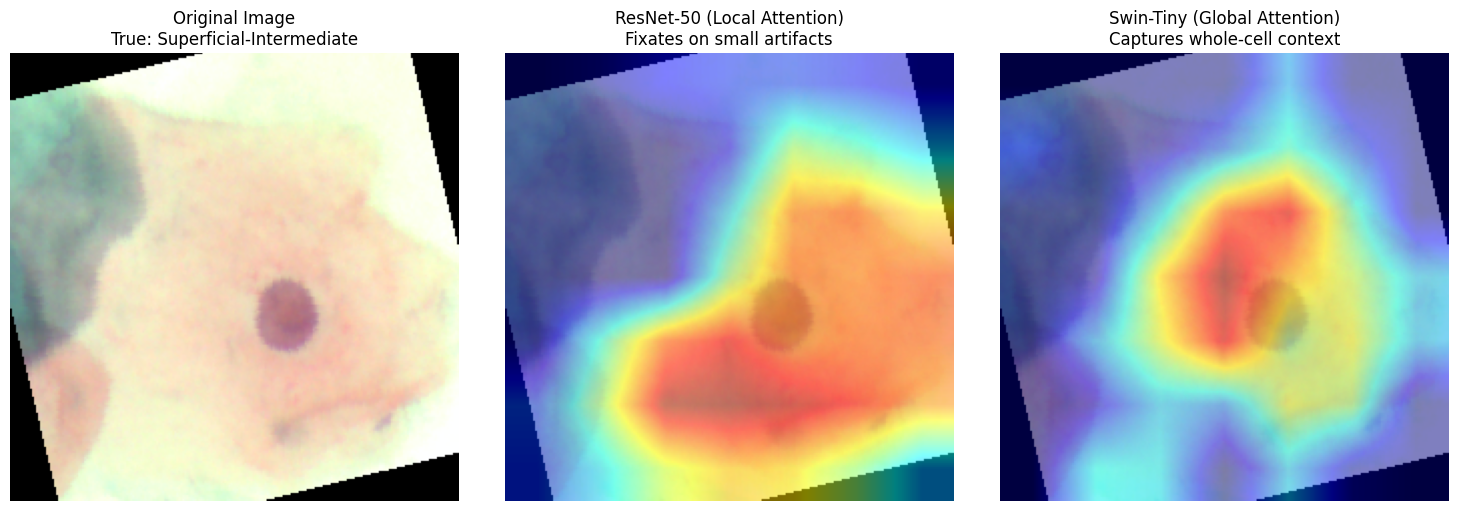

✅ High-resolution figure saved as 'gradcam_resnet_vs_swin_300dpi.png'


In [23]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import cv2
from torchvision import models, transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# 1. Device Setup and Model Initialization
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_names = ['Dyskeratotic', 'Koilocytotic', 'Metaplastic', 'Parabasal', 'Superficial-Intermediate']

# Load ResNet-50
resnet = models.resnet50()
resnet.fc = nn.Linear(resnet.fc.in_features, 5)
resnet.load_state_dict(torch.load('resnet50_sipakmed_baseline.pth', map_location=device, weights_only=True))
resnet = resnet.to(device)
resnet.eval()

# Load Swin-Tiny
swin = models.swin_t()
swin.head = nn.Linear(swin.head.in_features, 5)
swin.load_state_dict(torch.load('swin_tiny_sipakmed_baseline.pth', map_location=device, weights_only=True))
swin = swin.to(device)
swin.eval()

# 2. Define Target Layers and Swin Reshape Transform
# ResNet: Target the last convolutional block
target_layers_resnet = [resnet.layer4[-1]]

# Swin: Target the final Swin Transformer block (Stage 4)
# We must reshape the output from (B, H, W, C) to (B, C, H, W) to avoid window artifacts
def swin_reshape_transform(tensor):
    # tensor shape is typically (batch, height, width, channels) in torchvision Swin blocks
    return tensor.permute(0, 3, 1, 2)

target_layers_swin = [swin.features[7][-1]]
# Initialize CAMs
cam_resnet = GradCAM(model=resnet, target_layers=target_layers_resnet)
cam_swin = GradCAM(model=swin, target_layers=target_layers_swin, reshape_transform=swin_reshape_transform)

# 3. Data Hunting: Find the exact edge case
print("Hunting for the target edge-case image...")
found_image = False
original_image_tensor = None
true_label = None

for inputs, labels in val_loader:
    inputs = inputs.to(device)
    labels = labels.to(device)
    
    res_out = resnet(inputs)
    _, res_p = torch.max(res_out, 1)
    
    swin_out = swin(inputs)
    _, swin_p = torch.max(swin_out, 1)
    
    for i in range(len(labels)):
        t_lbl = labels[i].item()
        r_pred = res_p[i].item()
        s_pred = swin_p[i].item()
        
        # True = 4 (Sup-Int), ResNet = 1 (Koilo), Swin = 4 (Sup-Int)
        if t_lbl == 4 and r_pred == 1 and s_pred == 4:
            original_image_tensor = inputs[i].unsqueeze(0)
            true_label = t_lbl
            found_image = True
            break
            
    if found_image:
        break

if not found_image:
    print("Edge case not found in this pass. Re-run or ensure val_loader is un-shuffled.")
else:
    print("Image found! Generating heatmaps...")

    # 4. Image Un-Normalization for Display
    img_for_display = original_image_tensor.squeeze().cpu().permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_for_display = std * img_for_display + mean
    img_for_display = np.clip(img_for_display, 0, 1)

    # 5. Generate Heatmaps
    targets = [ClassifierOutputTarget(true_label)]

    # Generate masks
    grayscale_cam_resnet = cam_resnet(input_tensor=original_image_tensor, targets=targets)[0, :]
    grayscale_cam_swin = cam_swin(input_tensor=original_image_tensor, targets=targets)[0, :]

    # Create overlays (using cv2.COLORMAP_JET smoothly at 0.5 alpha)
    visualization_resnet = show_cam_on_image(img_for_display, grayscale_cam_resnet, use_rgb=True, colormap=cv2.COLORMAP_JET, image_weight=0.5)
    visualization_swin = show_cam_on_image(img_for_display, grayscale_cam_swin, use_rgb=True, colormap=cv2.COLORMAP_JET, image_weight=0.5)

    # 6. Plotting the IEEE Figure
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    axs[0].imshow(img_for_display)
    axs[0].set_title(f'Original Image\nTrue: {class_names[true_label]}', fontsize=12)
    axs[0].axis('off')

    axs[1].imshow(visualization_resnet)
    axs[1].set_title('ResNet-50 (Local Attention)\nFixates on small artifacts', fontsize=12)
    axs[1].axis('off')

    axs[2].imshow(visualization_swin)
    axs[2].set_title('Swin-Tiny (Global Attention)\nCaptures whole-cell context', fontsize=12)
    axs[2].axis('off')

    plt.tight_layout()
    
    # Save for publication at 300 DPI
    save_filename = 'gradcam_resnet_vs_swin_300dpi.png'
    plt.savefig(save_filename, dpi=300, bbox_inches='tight', format='png')
    plt.show()

    print(f"✅ High-resolution figure saved as '{save_filename}'")

In [2]:
import pandas as pd

performance_data = {
    "Architecture": ["ResNet-50 (CNN)", "Swin-Tiny (Transformer)"],
    "Peak Validation Accuracy": ["97.91%", "98.11%"],
    "Convergence Epoch": ["Epoch 12", "Epoch 10"]
}

df_perf = pd.DataFrame(performance_data)
print("--- Overall Model Performance Summary ---")
print(df_perf.to_markdown(index=False))

--- Overall Model Performance Summary ---
| Architecture            | Peak Validation Accuracy   | Convergence Epoch   |
|:------------------------|:---------------------------|:--------------------|
| ResNet-50 (CNN)         | 97.91%                     | Epoch 12            |
| Swin-Tiny (Transformer) | 98.11%                     | Epoch 10            |


In [4]:
import pandas as pd

hyperparams = {
    "Setting": ["Input Size", "Batch Size", "Epochs", "Optimizer", "Learning Rate", "Weight Decay", "Loss Function"],
    "Value": ["224x224", "32", "15", "AdamW", "1e-4", "1e-4", "Cross-EntropyLoss"]
}

df_hp = pd.DataFrame(hyperparams)
print("--- Training Configuration ---")
print(df_hp.to_markdown(index=False))

--- Training Configuration ---
| Setting       | Value             |
|:--------------|:------------------|
| Input Size    | 224x224           |
| Batch Size    | 32                |
| Epochs        | 15                |
| Optimizer     | AdamW             |
| Learning Rate | 1e-4              |
| Weight Decay  | 1e-4              |
| Loss Function | Cross-EntropyLoss |
